# VDJBet YF Analysis (Rmd-aligned)

Python rewrite of `tmp/vdjbet_snippet.Rmd` with matching analysis outputs:

1. YF vs OLGA V-usage and V/J correction factors
2. LLW reference and adjusted mock generation
3. LLW Pgen histogram match against mock bins
4. LLW overlap per sample: matched clonotypes and duplicate_count
5. Cohen d, z-scores, empirical p-values, FDR
6. Red line (LLW) + mock boxplots and Cohen d heatmaps

In [ ]:
import math
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from mir.basic.gene_usage import GeneUsage
from mir.basic.pgen import OlgaModel, PgenGeneUsageAdjustment
from mir.biomarkers.vdjbet import PgenBinPool, VDJBetOverlapAnalysis
from mir.common.parser import ClonotypeTableParser, load_vdjdb_latest
from mir.common.repertoire import LocusRepertoire, Repertoire

SEED = 42
N_MOCKS = 200
POOL_SIZE = 200_000
OLGA_USAGE_N = 1_000_000
# count_rearrangement (default, unweighted) or count_duplicates (weighted by duplicate_count)
USAGE_COUNT_MODE = "count_rearrangement"
USAGE_PSEUDOCOUNT = 1.0
YFV_CACHE_DIRNAME = "pkl_trb_repertoires"

YFV_PRIMARY_DIR = Path("notebooks/assets/large/yfv19")
_yfv_fallback_candidates = [
    Path("assets/large/yfv19"),
    Path("../notebooks/assets/large/yfv19"),
]
YFV_DIR = YFV_PRIMARY_DIR if YFV_PRIMARY_DIR.exists() else next(
    (p for p in _yfv_fallback_candidates if p.exists()),
    YFV_PRIMARY_DIR,
    )

print(f"YFV_DIR = {YFV_DIR}")
print(f"YFV_PRIMARY_DIR = {YFV_PRIMARY_DIR}")
print(f"Usage mode = {USAGE_COUNT_MODE}, pseudocount = {USAGE_PSEUDOCOUNT}")
print(f"OLGA usage cache size = {OLGA_USAGE_N:,}")

YFV_DIR = assets/large/yfv19
Usage mode = count_rearrangement, pseudocount = 1.0
OLGA usage cache size = 1,000,000


## 1. Load LLWNGPMAV TRB reference from VDJdb

In [2]:
vdjdb_rep = load_vdjdb_latest(
    epitope="LLWNGPMAV",
    locus="TRB",
    species="HomoSapiens",
    mhc_a_contains="A*02",
)
print(f"Reference clonotypes: {vdjdb_rep.clonotype_count}")
print(f"Example: {vdjdb_rep.clonotypes[0].junction_aa}  {vdjdb_rep.clonotypes[0].v_gene}  {vdjdb_rep.clonotypes[0].j_gene}")

Downloading: https://github.com/antigenomics/vdjdb-db/releases/download/2025-12-29/vdjdb-2025-12-29.zip
LLWNGPMAV: 409 unique TRB clonotypes
Reference clonotypes: 409
Example: CAIQDAGASYEQYF  TRBV6-2*01  TRBJ2-7*01


## 2. Load YF samples

In [ ]:
from mir.biomarkers.vdjbet import PgenBinPool, VDJBetOverlapAnalysis
from mir.basic.gene_usage import GeneUsage
from mir.basic.pgen import OlgaModel, PgenGeneUsageAdjustment
from mir.common.clonotype import Clonotype, Repertoire
from mir.common.filter import filter_functional
from mir.common.parser import ClonotypeTableParser
from mir.common.repertoire import LocusRepertoire

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import binom
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

Samples loaded: 42
Total TRB clonotypes across samples: 31,471,185
Combined unique clonotypes object size: 31,471,185
Pickle cache dir: assets/large/yfv19/pkl_trb_repertoires


## 3. OLGA usage and correction factors

Compute OLGA and YF usage frequencies, then derive correction factors.

Frequencies are computed in GeneUsage with configurable count mode and Laplace smoothing:

- mode count_rearrangement: count of unique clonotypes per key / total clonotypes
- mode count_duplicates: sum duplicate_count per key / total duplicate_count
- pseudocount 1 is added for both YF and OLGA sides

Formulas:

- factor_v = P_YF(V) / P_OLGA(V)
- factor_vj = P_YF(V,J) / P_OLGA(V,J)

These factors are used by PgenGeneUsageAdjustment.

Top V genes by |log2 factor|:


,v_gene,p_yf,p_olga,factor_v,log2_factor_v,abs_log2
21,TRBV21-1,0.008785,9.999520e-07,8785.169931,13.100854,13.100854
23,TRBV23-1,0.006480,9.999520e-07,6480.670321,12.661927,12.661927
8,TRBV12-2,0.000693,9.999520e-07,693.205634,9.437140,9.437140
0,TRBV1,0.000369,9.999520e-07,368.671637,8.526193,8.526193
31,TRBV3-2,0.000342,9.999520e-07,341.820445,8.417095,8.417095
50,TRBV6-7,0.000279,9.999520e-07,278.648646,8.122303,8.122303
38,TRBV5-3,0.000248,9.999520e-07,247.698277,7.952440,7.952440
7,TRBV12-1,0.000236,9.999520e-07,235.940950,7.882282,7.882282
42,TRBV5-7,0.000151,9.999520e-07,150.589113,7.234474,7.234474
62,TRBV8-2,0.000133,9.999520e-07,132.857793,7.053739,7.053739


Top VJ pairs by |log2 factor|:


,v_gene,j_gene,p_yf,p_olga,factor_vj,log2_factor_vj,abs_log2
305,TRBV21-1,TRBJ2-7,0.002132,9.993764e-07,2133.316229,11.058882,11.058882
333,TRBV23-1,TRBJ2-7,0.001593,9.993764e-07,1594.057584,10.638488,10.638488
298,TRBV21-1,TRBJ2-1,0.001514,9.993764e-07,1514.795052,10.564907,10.564907
326,TRBV23-1,TRBJ2-1,0.001212,9.993764e-07,1212.751710,10.244068,10.244068
303,TRBV21-1,TRBJ2-5,0.000907,9.993764e-07,907.846904,9.826305,9.826305
301,TRBV21-1,TRBJ2-3,0.000869,9.993764e-07,869.248945,9.763626,9.763626
329,TRBV23-1,TRBJ2-3,0.000783,9.993764e-07,783.118901,9.613088,9.613088
331,TRBV23-1,TRBJ2-5,0.000698,9.993764e-07,698.165237,9.447425,9.447425
299,TRBV21-1,TRBJ2-2,0.000628,9.993764e-07,628.250152,9.295195,9.295195
292,TRBV21-1,TRBJ1-1,0.000619,9.993764e-07,619.474998,9.274902,9.274902


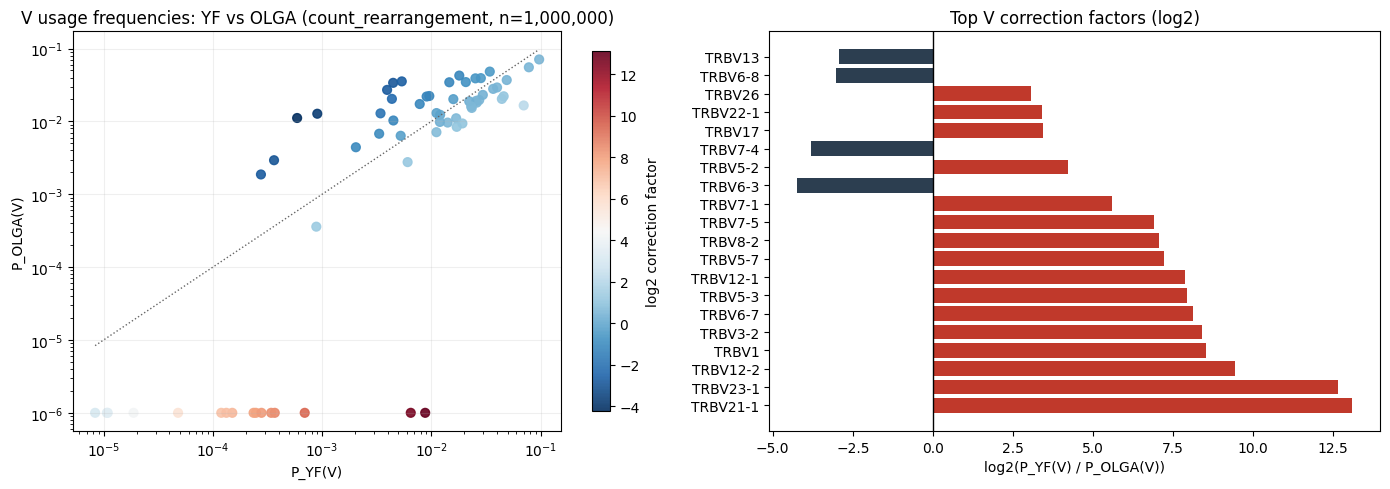

Zero-frequency OLGA V genes in comparison table: 0


In [4]:
olga_model = OlgaModel(locus="TRB", seed=SEED)
olga_gu = olga_model.compute_usage_cache(n=OLGA_USAGE_N, seed=SEED)

# Centralized frequency + factor computation from GeneUsage module
v_cmp = yfv_gu.usage_comparison(
    olga_gu,
    "TRB",
    scope="v",
    count=USAGE_COUNT_MODE,
    pseudocount=USAGE_PSEUDOCOUNT,
)
vj_cmp = yfv_gu.usage_comparison(
    olga_gu,
    "TRB",
    scope="vj",
    count=USAGE_COUNT_MODE,
    pseudocount=USAGE_PSEUDOCOUNT,
)

v_df = pd.DataFrame(
    [
        {
            "v_gene": k,
            "p_yf": vals["p_self"],
            "p_olga": vals["p_reference"],
            "factor_v": vals["factor"],
        }
        for k, vals in v_cmp.items()
    ]
)
v_df["log2_factor_v"] = np.log2(np.clip(v_df["factor_v"].values, 1e-300, None))

vj_df = pd.DataFrame(
    [
        {
            "v_gene": k[0],
            "j_gene": k[1],
            "p_yf": vals["p_self"],
            "p_olga": vals["p_reference"],
            "factor_vj": vals["factor"],
        }
        for k, vals in vj_cmp.items()
    ]
)
vj_df["log2_factor_vj"] = np.log2(np.clip(vj_df["factor_vj"].values, 1e-300, None))

pgen_adj = PgenGeneUsageAdjustment(
    yfv_gu,
    cache_size=OLGA_USAGE_N,
    seed=SEED,
    count=USAGE_COUNT_MODE,
    pseudocount=USAGE_PSEUDOCOUNT,
    reference=olga_gu,
)

print("Top V genes by |log2 factor|:")
display(v_df.assign(abs_log2=lambda d: d["log2_factor_v"].abs()).sort_values("abs_log2", ascending=False).head(15))
print("Top VJ pairs by |log2 factor|:")
display(vj_df.assign(abs_log2=lambda d: d["log2_factor_vj"].abs()).sort_values("abs_log2", ascending=False).head(15))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.clip(v_df["p_yf"].values, 1e-12, None)
y = np.clip(v_df["p_olga"].values, 1e-12, None)
sc = axes[0].scatter(x, y, c=v_df["log2_factor_v"].values, cmap="RdBu_r", s=40, alpha=0.9)
axes[0].plot([x.min(), x.max()], [x.min(), x.max()], color="#666666", linestyle=":", linewidth=1)
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("P_YF(V)")
axes[0].set_ylabel("P_OLGA(V)")
axes[0].set_title(f"V usage frequencies: YF vs OLGA ({USAGE_COUNT_MODE}, n={OLGA_USAGE_N:,})")
axes[0].grid(alpha=0.2)
cb = plt.colorbar(sc, ax=axes[0], shrink=0.9)
cb.set_label("log2 correction factor")

top = v_df.assign(abs_log2=lambda d: d["log2_factor_v"].abs()).sort_values("abs_log2", ascending=False).head(20)
axes[1].barh(top["v_gene"], top["log2_factor_v"], color=["#c0392b" if z > 0 else "#2c3e50" for z in top["log2_factor_v"]])
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("Top V correction factors (log2)")
axes[1].set_xlabel("log2(P_YF(V) / P_OLGA(V))")

plt.tight_layout()
plt.show()

print(f"Zero-frequency OLGA V genes in comparison table: {(v_df['p_olga'] == 0).sum()}")

## 4. Build adjusted pool and compare LLW Pgen histogram to mock bins

Pool built: n_generated=200,000, bins=62, floor=-79, ceil=-18, elapsed=350.6s


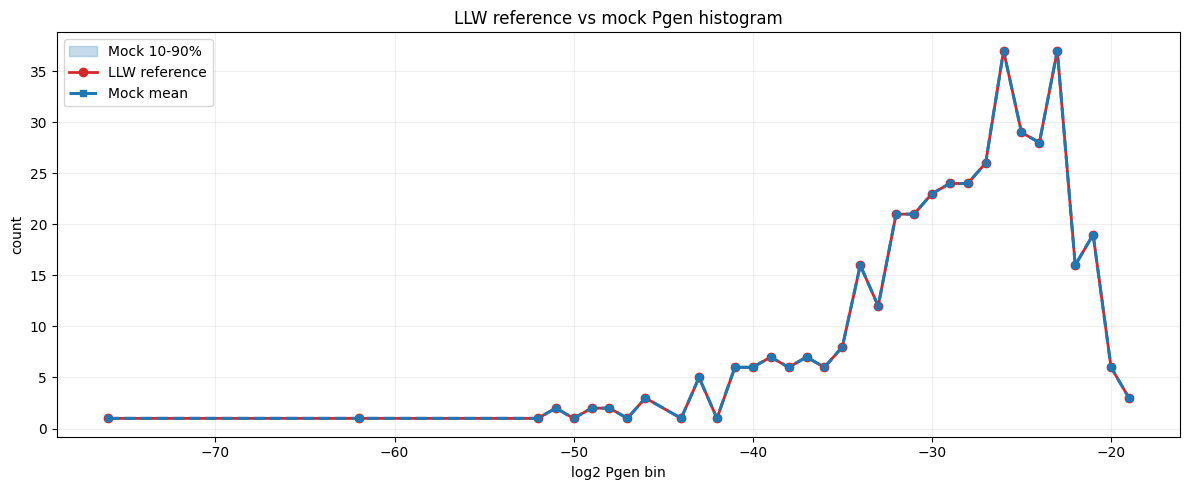

Mock vs LLW: median max|Delta p(bin)|=0.0000, p95=0.0000
Mock vs LLW: median RMSD=0.0000, p95=0.0000


In [5]:
t0 = pd.Timestamp.now()
pool = PgenBinPool(
    "TRB",
    n=POOL_SIZE,
    n_jobs=4,
    seed=SEED,
    pgen_adjustment=pgen_adj,
)
analysis = VDJBetOverlapAnalysis(
    vdjdb_rep,
    pool=pool,
    n_mocks=N_MOCKS,
    seed=SEED,
)
dt = (pd.Timestamp.now() - t0).total_seconds()
print(f"Pool built: n_generated={pool.n_generated:,}, bins={len(pool.bins)}, floor={pool.floor_bin}, ceil={pool.ceil_bin}, elapsed={dt:.1f}s")

ref_bins = analysis.get_reference_bin_sample()
mock_bins = analysis.get_mock_bin_samples()

ref_counts = Counter(ref_bins)
all_bins = sorted(ref_counts.keys())
if not all_bins:
    raise RuntimeError("No LLW reference bins available for diagnostics.")

mock_mat = []
for mb in mock_bins:
    mc = Counter(mb)
    mock_mat.append([mc.get(b, 0) for b in all_bins])
mock_mat = np.asarray(mock_mat, dtype=float)

ref_vec = np.array([ref_counts.get(b, 0) for b in all_bins], dtype=float)
mock_mean = mock_mat.mean(axis=0)
mock_q10 = np.quantile(mock_mat, 0.10, axis=0)
mock_q90 = np.quantile(mock_mat, 0.90, axis=0)

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(all_bins, mock_q10, mock_q90, alpha=0.25, color="#1f77b4", label="Mock 10-90%", zorder=1)
ax.plot(all_bins, ref_vec, color="#d62728", marker="o", linewidth=2, label="LLW reference", zorder=2)
# Draw mock mean last so it remains visible even when overlapping the reference line.
ax.plot(all_bins, mock_mean, color="#1f77b4", linestyle="--", marker="s", markersize=4, linewidth=2.2, label="Mock mean", zorder=3)
ax.set_xlabel("log2 Pgen bin")
ax.set_ylabel("count")
ax.set_title("LLW reference vs mock Pgen histogram")
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

ref_prob = ref_vec / max(ref_vec.sum(), 1.0)
mock_probs = mock_mat / np.clip(mock_mat.sum(axis=1, keepdims=True), 1.0, None)
max_abs_diff = np.max(np.abs(mock_probs - ref_prob[None, :]), axis=1)
rmsd = np.sqrt(np.mean((mock_probs - ref_prob[None, :]) ** 2, axis=1))
print(f"Mock vs LLW: median max|Delta p(bin)|={np.median(max_abs_diff):.4f}, p95={np.percentile(max_abs_diff,95):.4f}")
print(f"Mock vs LLW: median RMSD={np.median(rmsd):.4f}, p95={np.percentile(rmsd,95):.4f}")

## 5. LLW overlap per sample: matched clonotypes and duplicate_count

Compute for each donor/day/replica:
- real LLW overlap
- mock distribution summary
- z-score and empirical p-value
- Cohen d
- FDR-adjusted p-values

In [6]:
def bh_fdr(pvals):
    p = np.asarray(pvals, dtype=float)
    n = len(p)
    order = np.argsort(p)
    ranked = p[order]
    q = ranked * n / (np.arange(1, n + 1))
    q = np.minimum.accumulate(q[::-1])[::-1]
    q = np.clip(q, 0.0, 1.0)
    out = np.empty_like(q)
    out[order] = q
    return out

rows = []
for i, s in enumerate(samples, start=1):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", UserWarning)
        r = analysis.score(s["repertoire"], allow_1mm=False, match_v=True, match_j=True)

    mn = np.array(r.mock_n, dtype=float)
    mdc = np.array(r.mock_dc, dtype=float)
    mdc_log2 = np.log2(mdc + 1.0)
    real_dc_log2 = math.log2(r.dc + 1.0)

    mn_mean = float(np.mean(mn))
    mn_sd = float(np.std(mn, ddof=1)) if len(mn) > 1 else 0.0
    mdc_mean = float(np.mean(mdc_log2))
    mdc_sd = float(np.std(mdc_log2, ddof=1)) if len(mdc_log2) > 1 else 0.0

    z_n = (r.n - mn_mean) / mn_sd if mn_sd > 0 else 0.0
    z_dc = (real_dc_log2 - mdc_mean) / mdc_sd if mdc_sd > 0 else 0.0

    p_n_emp = (np.sum(mn >= r.n) + 1.0) / (len(mn) + 1.0)
    p_dc_emp = (np.sum(mdc_log2 >= real_dc_log2) + 1.0) / (len(mdc_log2) + 1.0)

    rows.append({
        "donor": s["donor"],
        "day": s["day"],
        "replica": s["replica"],
        "sample_label": f"{s['donor']} {s['replica']}",
        "n_total": r.n_total,
        "dc_total": r.dc_total,
        "matched_n_real": float(r.n),
        "matched_n_mock_mean": mn_mean,
        "matched_n_mock_sd": mn_sd,
        "matched_n_z": z_n,
        "matched_n_p_emp": p_n_emp,
        "matched_n_cohen_d": (r.n - mn_mean) / mn_sd if mn_sd > 0 else 0.0,
        "matched_dc_real": float(r.dc),
        "matched_dc_log2_real": real_dc_log2,
        "matched_dc_log2_mock_mean": mdc_mean,
        "matched_dc_log2_mock_sd": mdc_sd,
        "matched_dc_log2_z": z_dc,
        "matched_dc_log2_p_emp": p_dc_emp,
        "matched_dc_log2_cohen_d": (real_dc_log2 - mdc_mean) / mdc_sd if mdc_sd > 0 else 0.0,
        "mock_n": list(mn),
        "mock_dc_log2": list(mdc_log2),
    })

    if i % 10 == 0:
        print(f"Processed {i}/{len(samples)} samples")

df_res = pd.DataFrame(rows).sort_values(["donor", "replica", "day"]).reset_index(drop=True)
df_res["matched_n_p_adj"] = bh_fdr(df_res["matched_n_p_emp"].values)
df_res["matched_dc_log2_p_adj"] = bh_fdr(df_res["matched_dc_log2_p_emp"].values)

display(df_res[[
    "donor", "replica", "day",
    "matched_n_real", "matched_n_mock_mean", "matched_n_z", "matched_n_p_emp", "matched_n_cohen_d",
    "matched_dc_real", "matched_dc_log2_real", "matched_dc_log2_mock_mean", "matched_dc_log2_z", "matched_dc_log2_p_emp", "matched_dc_log2_cohen_d",
]])

Processed 10/42 samples
Processed 20/42 samples
Processed 30/42 samples
Processed 40/42 samples


,donor,replica,day,matched_n_real,matched_n_mock_mean,matched_n_z,matched_n_p_emp,matched_n_cohen_d,matched_dc_real,matched_dc_log2_real,matched_dc_log2_mock_mean,matched_dc_log2_z,matched_dc_log2_p_emp,matched_dc_log2_cohen_d
0,P1,F1,-1,11.0,8.200,0.988708,0.208955,0.988708,55.0,5.807355,3.997968,2.424392,0.024876,2.424392
1,P1,F1,0,13.0,7.415,1.897192,0.064677,1.897192,48.0,5.614710,3.669431,2.414268,0.009950,2.414268
2,P1,F1,7,21.0,10.090,3.649547,0.004975,3.649547,100.0,6.658211,4.391411,3.120825,0.004975,3.120825
3,P1,F1,15,28.0,10.710,5.756620,0.004975,5.756620,364.0,8.511753,4.667921,5.245105,0.004975,5.245105
4,P1,F1,45,18.0,7.815,3.747193,0.004975,3.747193,432.0,8.758223,3.834197,6.746946,0.004975,6.746946
5,P1,F2,0,11.0,7.280,1.414522,0.109453,1.414522,45.0,5.523562,3.575726,2.844872,0.004975,2.844872
6,P2,F1,-1,20.0,11.925,2.667298,0.014925,2.667298,61.0,5.954196,4.943086,1.549528,0.074627,1.549528
7,P2,F1,0,16.0,7.570,2.977632,0.004975,2.977632,41.0,5.392317,3.787503,2.283656,0.009950,2.283656
8,P2,F1,7,29.0,12.525,5.078981,0.004975,5.078981,88.0,6.475733,4.946362,2.437920,0.019900,2.437920
9,P2,F1,15,34.0,12.115,7.100704,0.004975,7.100704,278.0,8.124121,4.796503,5.396383,0.004975,5.396383


## 6. Lines (LLW real) and boxplots (mock)

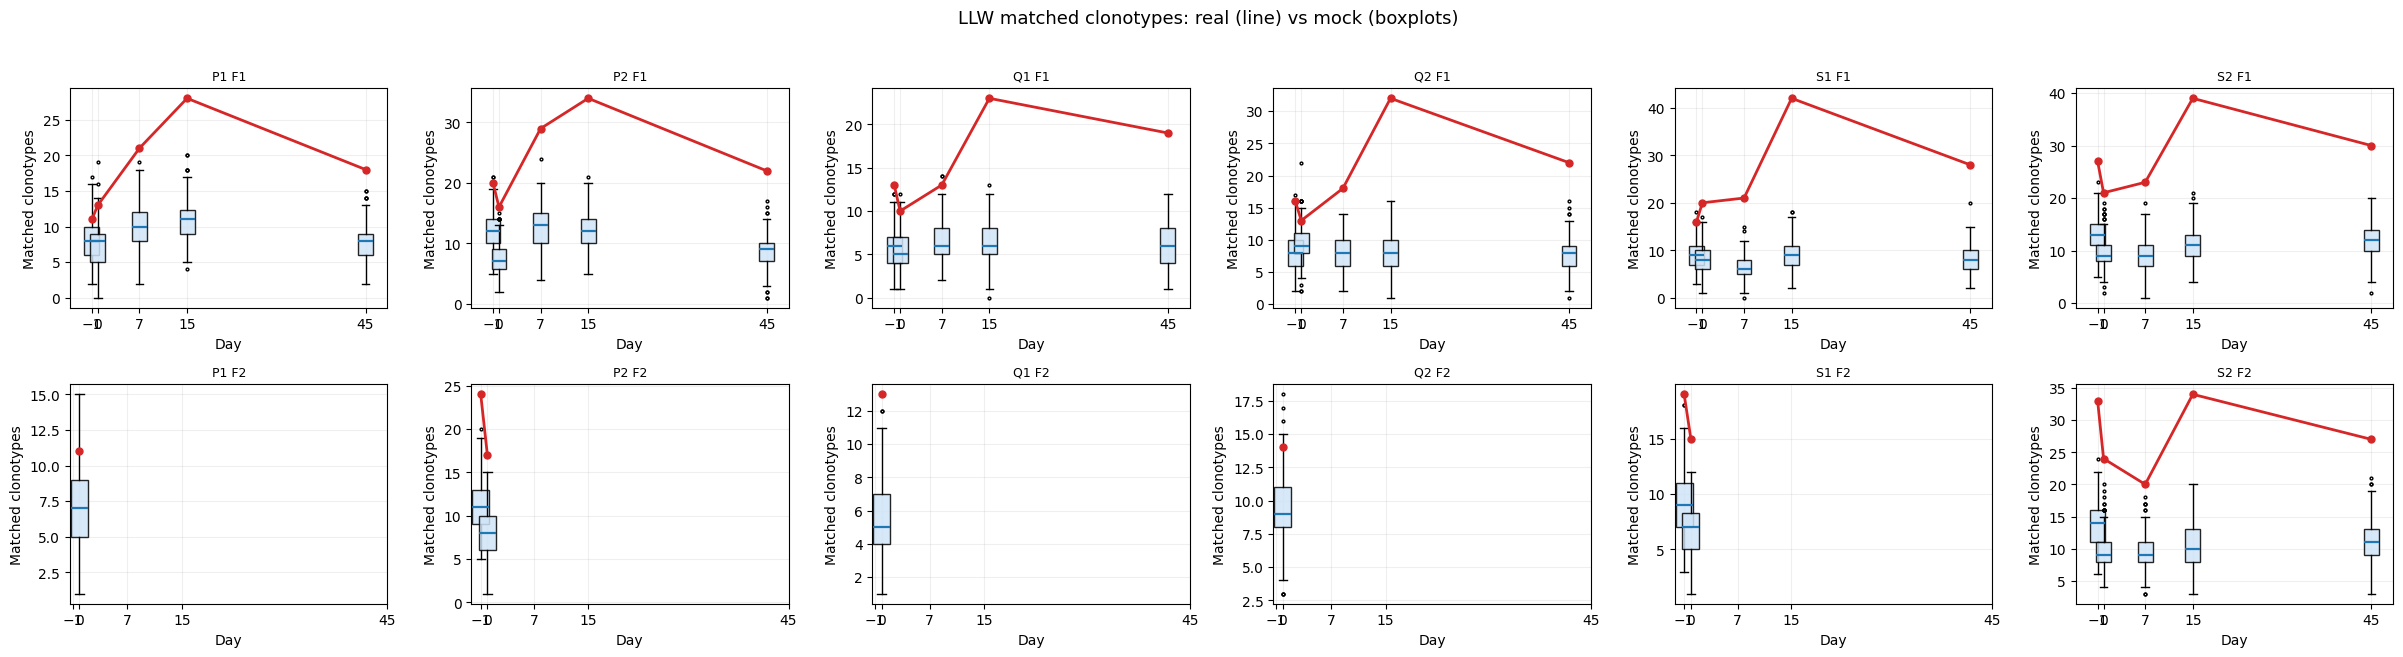

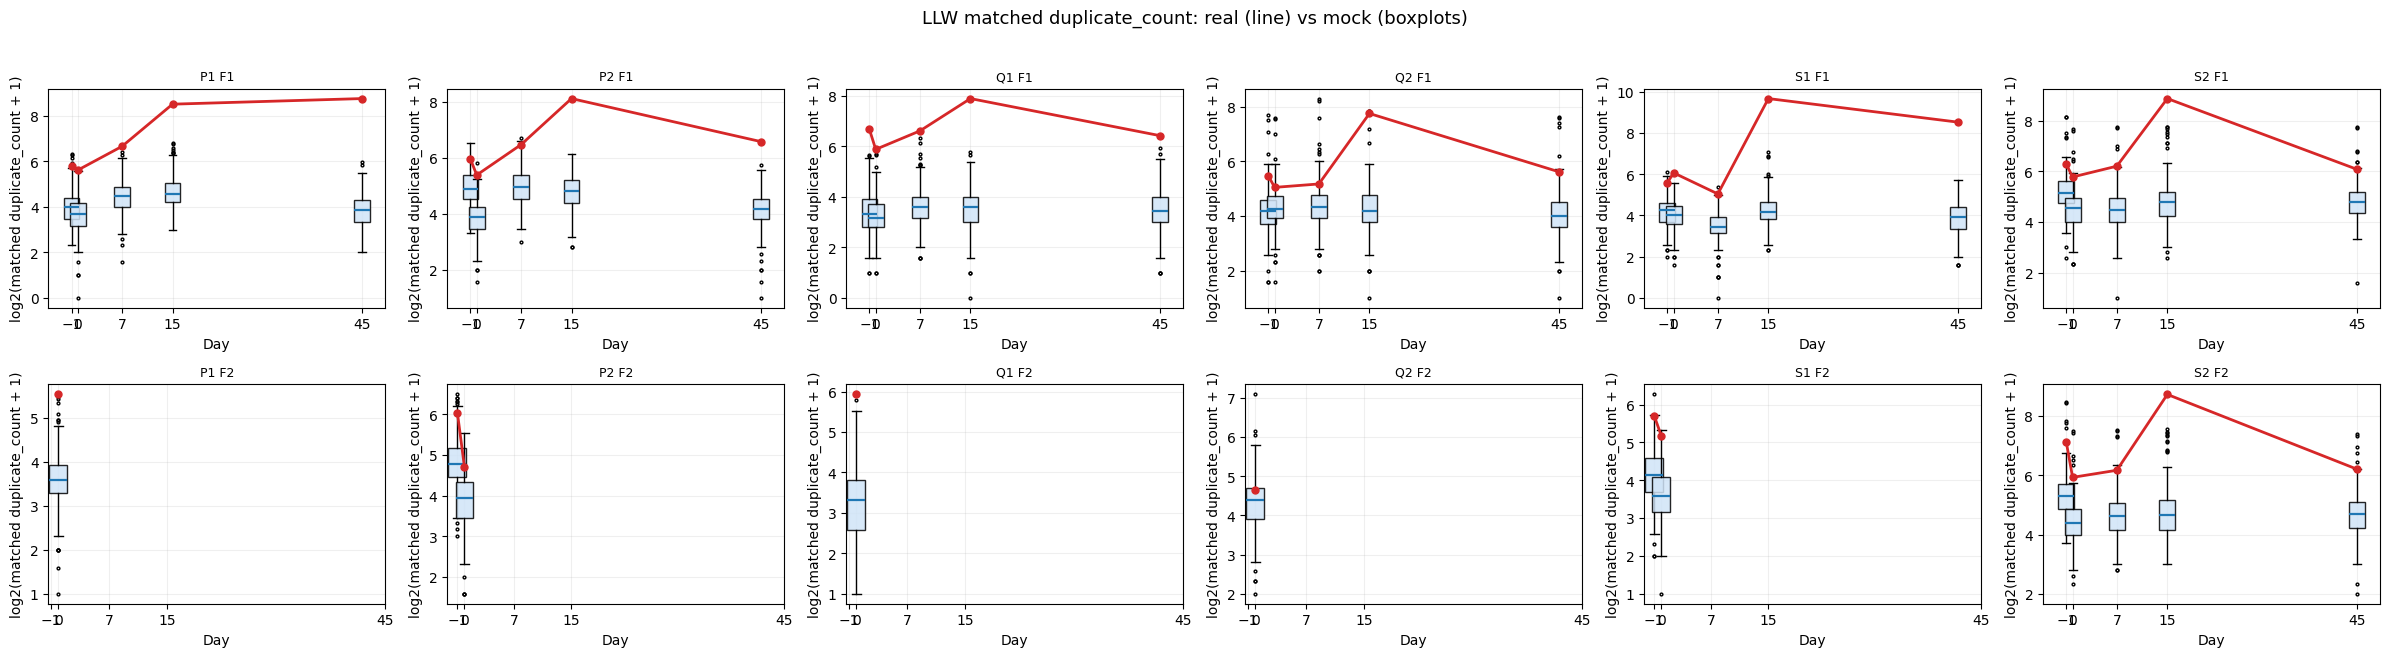

In [7]:
plot_rows = []
for _, r in df_res.iterrows():
    for x in r["mock_n"]:
        plot_rows.append({
            "donor": r["donor"], "replica": r["replica"], "day": int(r["day"]),
            "metric": "matched_n", "kind": "mock", "value": float(x),
        })
    plot_rows.append({
        "donor": r["donor"], "replica": r["replica"], "day": int(r["day"]),
        "metric": "matched_n", "kind": "real", "value": float(r["matched_n_real"]),
    })

    for x in r["mock_dc_log2"]:
        plot_rows.append({
            "donor": r["donor"], "replica": r["replica"], "day": int(r["day"]),
            "metric": "matched_dc_log2", "kind": "mock", "value": float(x),
        })
    plot_rows.append({
        "donor": r["donor"], "replica": r["replica"], "day": int(r["day"]),
        "metric": "matched_dc_log2", "kind": "real", "value": float(r["matched_dc_log2_real"]),
    })

plot_df = pd.DataFrame(plot_rows)
days_all = sorted(df_res["day"].unique().tolist())
donors = sorted(df_res["donor"].unique().tolist())
replicas = sorted(df_res["replica"].unique().tolist())

def draw_panel(metric, ylabel, title):
    fig, axes = plt.subplots(len(replicas), len(donors), figsize=(4.0 * len(donors), 3.2 * len(replicas)), squeeze=False)
    fig.suptitle(title, fontsize=13, y=1.02)
    for ri, rep in enumerate(replicas):
        for di, donor in enumerate(donors):
            ax = axes[ri, di]
            sub = plot_df[(plot_df["metric"] == metric) & (plot_df["donor"] == donor) & (plot_df["replica"] == rep)]
            if sub.empty:
                ax.set_visible(False)
                continue

            real = sub[sub["kind"] == "real"].sort_values("day")
            mock = sub[sub["kind"] == "mock"]
            box_data = [mock[mock["day"] == d]["value"].values for d in days_all]
            width = 2.5
            ax.boxplot(
                box_data,
                positions=days_all,
                widths=width,
                patch_artist=True,
                boxprops=dict(facecolor="#d0e4f7", alpha=0.85),
                medianprops=dict(color="#1f77b4", linewidth=1.6),
                flierprops=dict(markersize=2),
                manage_ticks=False,
            )
            ax.plot(real["day"], real["value"], "-o", color="#d62728", linewidth=2, markersize=5, zorder=5)
            ax.set_xticks(days_all)
            ax.set_xlabel("Day")
            ax.set_ylabel(ylabel)
            ax.set_title(f"{donor} {rep}", fontsize=9)
            ax.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

draw_panel("matched_n", "Matched clonotypes", "LLW matched clonotypes: real (line) vs mock (boxplots)")
draw_panel("matched_dc_log2", "log2(matched duplicate_count + 1)", "LLW matched duplicate_count: real (line) vs mock (boxplots)")

## 7. Cohen d heatmaps

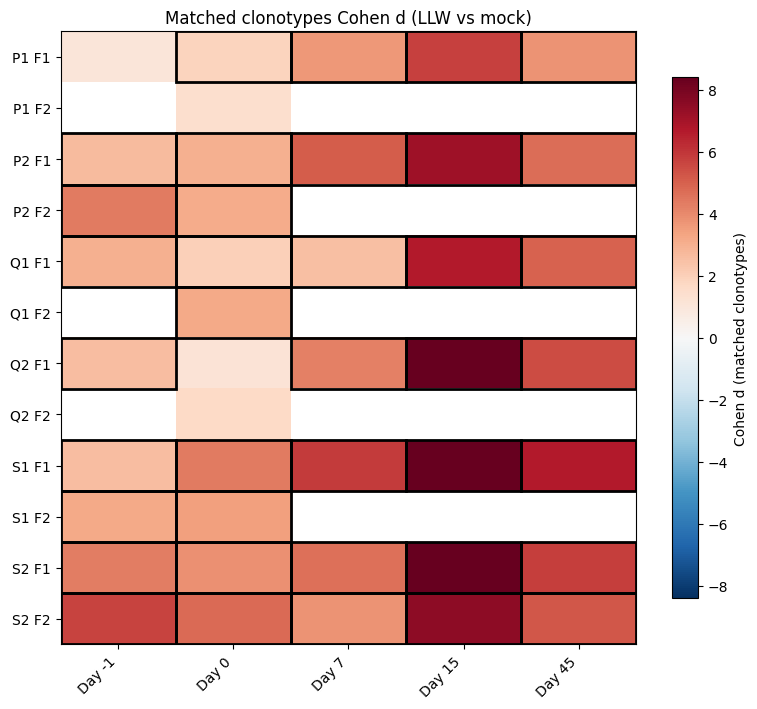

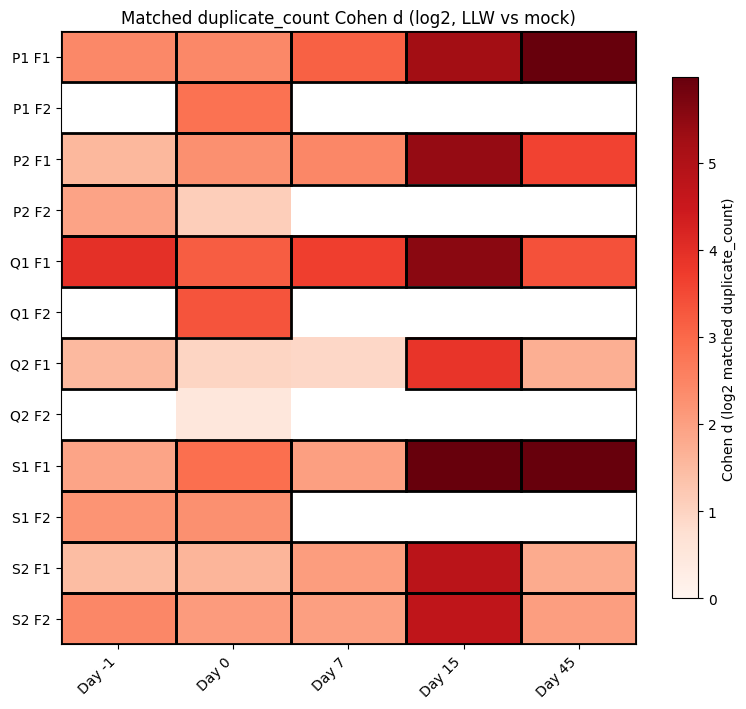

In [8]:
def heatmap_cohen(value_col, p_adj_col, title, cbar_label, cmap="RdBu_r", vlim=None):
    work = df_res.copy()
    work["sample"] = work["donor"] + " " + work["replica"]
    pv = work.pivot_table(index="sample", columns="day", values=value_col, aggfunc="first")
    pp = work.pivot_table(index="sample", columns="day", values=p_adj_col, aggfunc="first")

    mat = pv.values.astype(float)
    if vlim is None:
        vmax = max(1.0, np.nanpercentile(np.abs(mat), 95))
        vmin = -vmax
    else:
        vmin, vmax = vlim

    fig, ax = plt.subplots(figsize=(8, max(3.5, 0.6 * pv.shape[0])))
    im = ax.imshow(mat, cmap=cmap, aspect="auto", vmin=vmin, vmax=vmax, interpolation="nearest")
    cb = plt.colorbar(im, ax=ax, shrink=0.85)
    cb.set_label(cbar_label)

    for r in range(pv.shape[0]):
        for c in range(pv.shape[1]):
            p = pp.values[r, c]
            d = pv.values[r, c]
            if pd.notna(p) and pd.notna(d) and (float(p) < 0.10) and (float(d) > 0):
                ax.add_patch(plt.Rectangle((c - 0.5, r - 0.5), 1, 1, fill=False, edgecolor="black", linewidth=2))

    ax.set_xticks(range(len(pv.columns)))
    ax.set_xticklabels([f"Day {d}" for d in pv.columns], rotation=45, ha="right")
    ax.set_yticks(range(len(pv.index)))
    ax.set_yticklabels(pv.index)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

heatmap_cohen(
    value_col="matched_n_cohen_d",
    p_adj_col="matched_n_p_adj",
    title="Matched clonotypes Cohen d (LLW vs mock)",
    cbar_label="Cohen d (matched clonotypes)",
    cmap="RdBu_r",
)

heatmap_cohen(
    value_col="matched_dc_log2_cohen_d",
    p_adj_col="matched_dc_log2_p_adj",
    title="Matched duplicate_count Cohen d (log2, LLW vs mock)",
    cbar_label="Cohen d (log2 matched duplicate_count)",
    cmap="Reds",
    vlim=(0, max(1.0, np.nanpercentile(df_res["matched_dc_log2_cohen_d"].values, 95))),
)

## 8. Final summary tables

In [9]:
summary_cols = [
    "donor", "replica", "day",
    "matched_n_real", "matched_n_mock_mean", "matched_n_mock_sd", "matched_n_cohen_d", "matched_n_z", "matched_n_p_emp", "matched_n_p_adj",
    "matched_dc_real", "matched_dc_log2_real", "matched_dc_log2_mock_mean", "matched_dc_log2_mock_sd",
    "matched_dc_log2_cohen_d", "matched_dc_log2_z", "matched_dc_log2_p_emp", "matched_dc_log2_p_adj",
]
summary = df_res[summary_cols].copy()
for col in [
    "matched_n_real", "matched_n_mock_mean", "matched_n_mock_sd", "matched_n_cohen_d", "matched_n_z",
    "matched_dc_real", "matched_dc_log2_real", "matched_dc_log2_mock_mean", "matched_dc_log2_mock_sd",
    "matched_dc_log2_cohen_d", "matched_dc_log2_z",
]:
    summary[col] = summary[col].astype(float).round(3)
for col in ["matched_n_p_emp", "matched_n_p_adj", "matched_dc_log2_p_emp", "matched_dc_log2_p_adj"]:
    summary[col] = summary[col].map(lambda x: f"{x:.4f}")

display(summary.sort_values(["donor", "replica", "day"]).reset_index(drop=True))

print("Top positive matched clonotype effects by Cohen d:")
display(summary.sort_values("matched_n_cohen_d", ascending=False).head(12))

print("Top positive matched duplicate_count effects by Cohen d:")
display(summary.sort_values("matched_dc_log2_cohen_d", ascending=False).head(12))

,donor,replica,day,matched_n_real,matched_n_mock_mean,matched_n_mock_sd,matched_n_cohen_d,matched_n_z,matched_n_p_emp,matched_n_p_adj,matched_dc_real,matched_dc_log2_real,matched_dc_log2_mock_mean,matched_dc_log2_mock_sd,matched_dc_log2_cohen_d,matched_dc_log2_z,matched_dc_log2_p_emp,matched_dc_log2_p_adj
0,P1,F1,-1,11.0,8.200,2.832,0.989,0.989,0.2090,0.2090,55.0,5.807,3.998,0.746,2.424,2.424,0.0249,0.0402
1,P1,F1,0,13.0,7.415,2.944,1.897,1.897,0.0647,0.0715,48.0,5.615,3.669,0.806,2.414,2.414,0.0100,0.0199
2,P1,F1,7,21.0,10.090,2.989,3.650,3.650,0.0050,0.0075,100.0,6.658,4.391,0.726,3.121,3.121,0.0050,0.0123
3,P1,F1,15,28.0,10.710,3.003,5.757,5.757,0.0050,0.0075,364.0,8.512,4.668,0.733,5.245,5.245,0.0050,0.0123
4,P1,F1,45,18.0,7.815,2.718,3.747,3.747,0.0050,0.0075,432.0,8.758,3.834,0.730,6.747,6.747,0.0050,0.0123
5,P1,F2,0,11.0,7.280,2.630,1.415,1.415,0.1095,0.1149,45.0,5.524,3.576,0.685,2.845,2.845,0.0050,0.0123
6,P2,F1,-1,20.0,11.925,3.027,2.667,2.667,0.0149,0.0196,61.0,5.954,4.943,0.653,1.550,1.550,0.0746,0.0825
7,P2,F1,0,16.0,7.570,2.831,2.978,2.978,0.0050,0.0075,41.0,5.392,3.788,0.703,2.284,2.284,0.0100,0.0199
8,P2,F1,7,29.0,12.525,3.244,5.079,5.079,0.0050,0.0075,88.0,6.476,4.946,0.627,2.438,2.438,0.0199,0.0348
9,P2,F1,15,34.0,12.115,3.082,7.101,7.101,0.0050,0.0075,278.0,8.124,4.797,0.617,5.396,5.396,0.0050,0.0123


Top positive matched clonotype effects by Cohen d:


,donor,replica,day,matched_n_real,matched_n_mock_mean,matched_n_mock_sd,matched_n_cohen_d,matched_n_z,matched_n_p_emp,matched_n_p_adj,matched_dc_real,matched_dc_log2_real,matched_dc_log2_mock_mean,matched_dc_log2_mock_sd,matched_dc_log2_cohen_d,matched_dc_log2_z,matched_dc_log2_p_emp,matched_dc_log2_p_adj
28,S1,F1,15,42.0,9.075,2.888,11.400,11.400,0.0050,0.0075,814.0,9.671,4.205,0.793,6.891,6.891,0.0050,0.0123
35,S2,F1,15,39.0,11.250,3.206,8.655,8.655,0.0050,0.0075,471.0,8.883,4.796,0.853,4.791,4.791,0.0050,0.0123
22,Q2,F1,15,32.0,8.195,2.817,8.450,8.450,0.0050,0.0075,214.0,7.748,4.229,0.912,3.858,3.858,0.0149,0.0285
40,S2,F2,15,34.0,10.415,3.136,7.522,7.522,0.0050,0.0075,424.0,8.731,4.736,0.849,4.707,4.707,0.0050,0.0123
9,P2,F1,15,34.0,12.115,3.082,7.101,7.101,0.0050,0.0075,278.0,8.124,4.797,0.617,5.396,5.396,0.0050,0.0123
29,S1,F1,45,28.0,8.390,2.934,6.683,6.683,0.0050,0.0075,368.0,8.527,3.890,0.773,6.000,6.000,0.0050,0.0123
16,Q1,F1,15,23.0,6.435,2.489,6.654,6.654,0.0050,0.0075,237.0,7.895,3.493,0.794,5.547,5.547,0.0050,0.0123
27,S1,F1,7,21.0,6.455,2.480,5.866,5.866,0.0050,0.0075,32.0,5.044,3.480,0.784,1.995,1.995,0.0100,0.0199
36,S2,F1,45,30.0,11.710,3.138,5.829,5.829,0.0050,0.0075,67.0,6.087,4.790,0.729,1.779,1.779,0.0448,0.0570
3,P1,F1,15,28.0,10.710,3.003,5.757,5.757,0.0050,0.0075,364.0,8.512,4.668,0.733,5.245,5.245,0.0050,0.0123


Top positive matched duplicate_count effects by Cohen d:


,donor,replica,day,matched_n_real,matched_n_mock_mean,matched_n_mock_sd,matched_n_cohen_d,matched_n_z,matched_n_p_emp,matched_n_p_adj,matched_dc_real,matched_dc_log2_real,matched_dc_log2_mock_mean,matched_dc_log2_mock_sd,matched_dc_log2_cohen_d,matched_dc_log2_z,matched_dc_log2_p_emp,matched_dc_log2_p_adj
28,S1,F1,15,42.0,9.075,2.888,11.400,11.400,0.0050,0.0075,814.0,9.671,4.205,0.793,6.891,6.891,0.0050,0.0123
4,P1,F1,45,18.0,7.815,2.718,3.747,3.747,0.0050,0.0075,432.0,8.758,3.834,0.730,6.747,6.747,0.0050,0.0123
29,S1,F1,45,28.0,8.390,2.934,6.683,6.683,0.0050,0.0075,368.0,8.527,3.890,0.773,6.000,6.000,0.0050,0.0123
16,Q1,F1,15,23.0,6.435,2.489,6.654,6.654,0.0050,0.0075,237.0,7.895,3.493,0.794,5.547,5.547,0.0050,0.0123
9,P2,F1,15,34.0,12.115,3.082,7.101,7.101,0.0050,0.0075,278.0,8.124,4.797,0.617,5.396,5.396,0.0050,0.0123
3,P1,F1,15,28.0,10.710,3.003,5.757,5.757,0.0050,0.0075,364.0,8.512,4.668,0.733,5.245,5.245,0.0050,0.0123
35,S2,F1,15,39.0,11.250,3.206,8.655,8.655,0.0050,0.0075,471.0,8.883,4.796,0.853,4.791,4.791,0.0050,0.0123
40,S2,F2,15,34.0,10.415,3.136,7.522,7.522,0.0050,0.0075,424.0,8.731,4.736,0.849,4.707,4.707,0.0050,0.0123
13,Q1,F1,-1,13.0,5.910,2.371,2.991,2.991,0.0199,0.0239,101.0,6.672,3.422,0.824,3.946,3.946,0.0050,0.0123
22,Q2,F1,15,32.0,8.195,2.817,8.450,8.450,0.0050,0.0075,214.0,7.748,4.229,0.912,3.858,3.858,0.0149,0.0285


Notebook output coverage checklist:

- V usage YF vs OLGA and correction factors
- LLW reference vs mock Pgen histogram alignment
- Matched clonotypes and duplicate_count per sample
- Cohen d, z-scores, empirical p-values, FDR
- Line + boxplot dynamics and Cohen d heatmaps

In [10]:
print("Done: notebook rewritten to Rmd-aligned workflow.")
print(f"Samples: {len(samples)}, mocks: {N_MOCKS}, pool size: {POOL_SIZE:,}")
print("Use the summary table above for export/reporting.")

Done: notebook rewritten to Rmd-aligned workflow.
Samples: 42, mocks: 200, pool size: 200,000
Use the summary table above for export/reporting.
